# 📊 Clase 3 — Estadística
## Fundamentos del método científico y probabilidad

**Desafío inicial:** Trabajas en una fundación educativa que implementó un programa piloto con herramientas digitales en escuelas. Deben evaluar su impacto con datos confiables antes de expandirlo. ¿Cómo planificar una investigación que garantice resultados estadísticamente válidos y aplicables?

**Objetivos:**
- Comprender el **pensamiento estadístico** y sus componentes clave
- Reconocer el rol de la estadística en el diseño de la investigación
- Dominar los fundamentos de la **inferencia estadística** (estimación y contraste)
- Interpretar el **valor p** y la significancia estadística
- Analizar los elementos de un **diseño experimental riguroso**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías cargadas')

✅ Librerías cargadas


---
## PARTE 1 — Pensamiento estadístico

### 1.1 Componentes clave — slide 6

In [2]:
# Tabla slide 6
tabla_pens = pd.DataFrame({
    'Componente': ['Contextualización','Variabilidad','Modelos probabilísticos','Decisión informada'],
    'Descripción': [
        'Los datos deben analizarse en su contexto social, cultural y temporal.',
        'Todo fenómeno natural presenta variación; es clave aprender a cuantificarla.',
        'Permiten explicar y predecir comportamientos con incertidumbre.',
        'Se toman decisiones basadas en evidencia empírica, no en intuiciones.'
    ]
})
print('=== Componentes del pensamiento estadístico (slide 6) ===')
print(tabla_pens.to_string(index=False))

=== Componentes del pensamiento estadístico (slide 6) ===
             Componente                                                                  Descripción
      Contextualización       Los datos deben analizarse en su contexto social, cultural y temporal.
           Variabilidad Todo fenómeno natural presenta variación; es clave aprender a cuantificarla.
Modelos probabilísticos              Permiten explicar y predecir comportamientos con incertidumbre.
     Decisión informada        Se toman decisiones basadas en evidencia empírica, no en intuiciones.


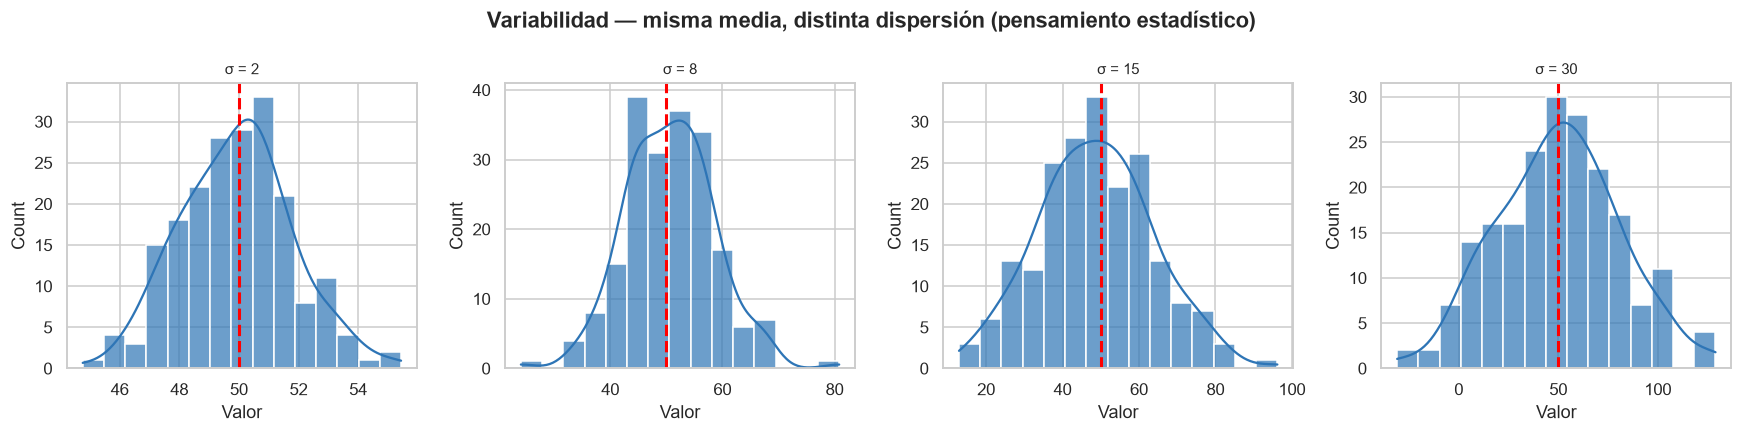

Ignorar la variabilidad lleva a conclusiones erróneas aunque la media sea la misma.


In [3]:
# Demostración: variabilidad es inevitable y debe cuantificarse
np.random.seed(42)
n_grupos = 4
media = 50

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Variabilidad — misma media, distinta dispersión (pensamiento estadístico)',
             fontweight='bold')

varianzas = [2, 8, 15, 30]
for ax, sigma in zip(axes, varianzas):
    datos = np.random.normal(media, sigma, 200)
    sns.histplot(datos, bins=15, kde=True, ax=ax, color='#2E75B6', alpha=0.7)
    ax.axvline(media, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'σ = {sigma}', fontsize=10)
    ax.set_xlabel('Valor')

plt.tight_layout()
plt.show()
print('Ignorar la variabilidad lleva a conclusiones erróneas aunque la media sea la misma.')

---
## PARTE 2 — Estadística en el diseño de la investigación

### 2.1 Etapas donde interviene la estadística — slide 10

In [4]:
tabla_etapas = pd.DataFrame({
    'Etapa': [
        'Planteamiento del problema',
        'Formulación de hipótesis',
        'Selección de la muestra',
        'Diseño del experimento',
        'Recolección y análisis de datos'
    ],
    'Contribución estadística': [
        'Permite definir variables medibles y objetivos de análisis.',
        'Establece relaciones que puedan validarse con pruebas estadísticas.',
        'Determina el tamaño y método de muestreo para garantizar representatividad.',
        'Define tipo de estudio, control de variables y asignación de tratamientos.',
        'Define métodos para evitar sesgos y seleccionar técnicas de análisis.'
    ]
})
print('=== Rol de la estadística en el diseño (slide 10) ===')
print(tabla_etapas.to_string(index=False))

=== Rol de la estadística en el diseño (slide 10) ===
                          Etapa                                                    Contribución estadística
     Planteamiento del problema                 Permite definir variables medibles y objetivos de análisis.
       Formulación de hipótesis         Establece relaciones que puedan validarse con pruebas estadísticas.
        Selección de la muestra Determina el tamaño y método de muestreo para garantizar representatividad.
         Diseño del experimento  Define tipo de estudio, control de variables y asignación de tratamientos.
Recolección y análisis de datos       Define métodos para evitar sesgos y seleccionar técnicas de análisis.


In [5]:
# Tipos de estudio y herramientas estadísticas — slide 11
tabla_tipos = pd.DataFrame({
    'Tipo de estudio': ['Descriptivo','Correlacional','Experimental','Cuasi-experimental'],
    'Características': [
        'Describe fenómenos, sin buscar relaciones causales.',
        'Examina relaciones entre variables.',
        'Manipula variables para observar efectos.',
        'No hay asignación aleatoria, pero se manipulan variables.'
    ],
    'Herramientas estadísticas': [
        'Tablas de frecuencia, medidas de tendencia central',
        'Correlación, regresión simple',
        'Pruebas t, ANOVA, regresión múltiple',
        'ANCOVA, modelos mixtos'
    ]
})
print('=== Tipos de estudio y herramientas (slide 11) ===')
print(tabla_tipos.to_string(index=False))

=== Tipos de estudio y herramientas (slide 11) ===
   Tipo de estudio                                           Características                          Herramientas estadísticas
       Descriptivo       Describe fenómenos, sin buscar relaciones causales. Tablas de frecuencia, medidas de tendencia central
     Correlacional                       Examina relaciones entre variables.                      Correlación, regresión simple
      Experimental                 Manipula variables para observar efectos.               Pruebas t, ANOVA, regresión múltiple
Cuasi-experimental No hay asignación aleatoria, pero se manipulan variables.                             ANCOVA, modelos mixtos


---
## PARTE 3 — Inferencia estadística

### 3.1 Tipos de inferencia — slide 16

In [6]:
tabla_infer = pd.DataFrame({
    'Tipo': ['Estimación','Contraste de hipótesis'],
    'Descripción': [
        'Cálculo de parámetros poblacionales (media, proporción, desv.std) a partir de una muestra.',
        'Evaluación formal de afirmaciones sobre una población; ¿los datos apoyan o refutan H0?'
    ],
    'Herramientas': [
        'Estimaciones puntuales, intervalos de confianza',
        'Pruebas t, chi-cuadrado, ANOVA, valor p'
    ]
})
print('=== Tipos de inferencia estadística (slide 16) ===')
print(tabla_infer.to_string(index=False))

=== Tipos de inferencia estadística (slide 16) ===
                  Tipo                                                                                Descripción                                    Herramientas
            Estimación Cálculo de parámetros poblacionales (media, proporción, desv.std) a partir de una muestra. Estimaciones puntuales, intervalos de confianza
Contraste de hipótesis     Evaluación formal de afirmaciones sobre una población; ¿los datos apoyan o refutan H0?         Pruebas t, chi-cuadrado, ANOVA, valor p


In [7]:
# Demostración: estimación puntual e intervalos de confianza
np.random.seed(42)
# Simulación: rendimiento académico de una población grande
poblacion = np.random.normal(loc=65, scale=12, size=10000)
# Muestra de 50 estudiantes
muestra   = np.random.choice(poblacion, size=50, replace=False)

media_muestra = muestra.mean()
std_muestra   = muestra.std(ddof=1)
n             = len(muestra)
se            = std_muestra / np.sqrt(n)

# IC 95%
ic_95 = stats.t.interval(0.95, df=n-1, loc=media_muestra, scale=se)
# IC 99%
ic_99 = stats.t.interval(0.99, df=n-1, loc=media_muestra, scale=se)

print('=== Estimación puntual e intervalos de confianza ===')
print(f'Media poblacional real:         {poblacion.mean():.2f}  (generalmente desconocida)')
print(f'Media muestral (n={n}):          {media_muestra:.2f}  ← estimación puntual')
print(f'Desv. std muestral:             {std_muestra:.2f}')
print(f'Error estándar:                 {se:.2f}')
print(f'IC 95%: [{ic_95[0]:.2f} — {ic_95[1]:.2f}]   ← interpretación: 95% de probabilidad que la media real esté aquí')
print(f'IC 99%: [{ic_99[0]:.2f} — {ic_99[1]:.2f}]   ← más ancho = más confianza = menos precisión')

=== Estimación puntual e intervalos de confianza ===
Media poblacional real:         64.97  (generalmente desconocida)
Media muestral (n=50):          65.71  ← estimación puntual
Desv. std muestral:             12.67
Error estándar:                 1.79
IC 95%: [62.11 — 69.31]   ← interpretación: 95% de probabilidad que la media real esté aquí
IC 99%: [60.91 — 70.51]   ← más ancho = más confianza = menos precisión


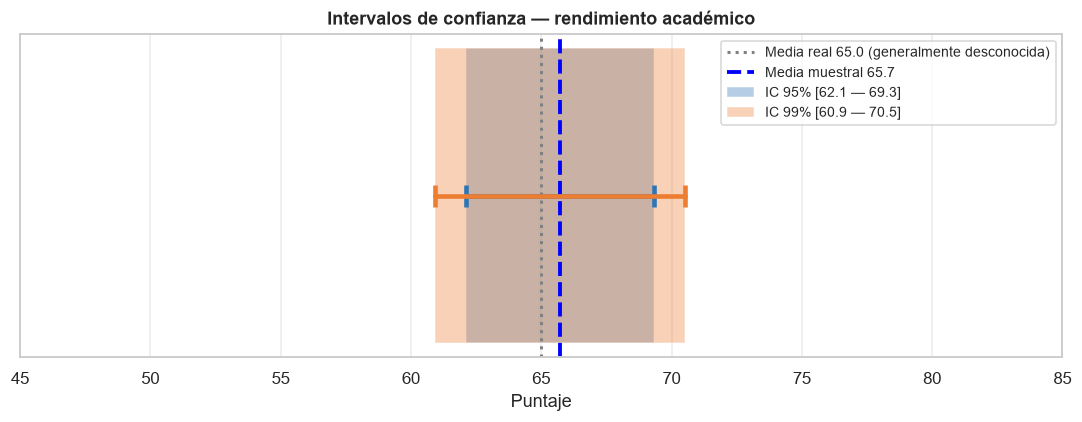

In [8]:
# Visualización de intervalos de confianza
fig, ax = plt.subplots(figsize=(10, 4))

ax.axvline(poblacion.mean(), color='gray', linestyle=':', linewidth=2,
           label=f'Media real {poblacion.mean():.1f} (generalmente desconocida)')
ax.axvline(media_muestra, color='blue', linestyle='--', linewidth=2.5,
           label=f'Media muestral {media_muestra:.1f}')

for ic, color, lbl in [
    (ic_95, '#2E75B6', 'IC 95%'),
    (ic_99, '#ED7D31', 'IC 99%')
]:
    ax.barh(0, ic[1]-ic[0], left=ic[0], height=0.25, color=color,
            alpha=0.35, label=f'{lbl} [{ic[0]:.1f} — {ic[1]:.1f}]')
    ax.plot([ic[0], ic[1]], [0, 0], color=color, linewidth=3)
    ax.plot(ic[0], 0, '|', color=color, markersize=15, markeredgewidth=3)
    ax.plot(ic[1], 0, '|', color=color, markersize=15, markeredgewidth=3)

ax.set_xlim(45, 85)
ax.set_yticks([])
ax.set_title('Intervalos de confianza — rendimiento académico', fontweight='bold')
ax.set_xlabel('Puntaje')
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

---
## PARTE 4 — Significancia estadística

### 4.1 Elementos y regla de decisión — slides 22-23

In [9]:
# Tabla slide 22
tabla_sig = pd.DataFrame({
    'Elemento': ['Hipótesis nula (H₀)','Hipótesis alternativa (H₁)',
                 'Nivel de significancia (α)','Valor p'],
    'Significado': [
        'Supone que no hay efecto o diferencia.',
        'Plantea que sí hay un efecto significativo.',
        'Límite de tolerancia al error tipo I (comúnmente 0.05).',
        'Probabilidad de obtener resultados tan extremos si H₀ es cierta.'
    ]
})
print('=== Elementos de la significancia estadística (slide 22) ===')
print(tabla_sig.to_string(index=False))
print()
print('REGLA DE DECISIÓN (slide 23):')
print('  Si p < α   → se RECHAZA H₀  → resultado estadísticamente significativo')
print('  Si p ≥ α   → NO se rechaza H₀ → no hay evidencia suficiente')

=== Elementos de la significancia estadística (slide 22) ===
                  Elemento                                                      Significado
       Hipótesis nula (H₀)                           Supone que no hay efecto o diferencia.
Hipótesis alternativa (H₁)                      Plantea que sí hay un efecto significativo.
Nivel de significancia (α)          Límite de tolerancia al error tipo I (comúnmente 0.05).
                   Valor p Probabilidad de obtener resultados tan extremos si H₀ es cierta.

REGLA DE DECISIÓN (slide 23):
  Si p < α   → se RECHAZA H₀  → resultado estadísticamente significativo
  Si p ≥ α   → NO se rechaza H₀ → no hay evidencia suficiente


In [11]:
# Ejemplo prueba A/B — slide 23
np.random.seed(42)
n_ab = 100

# Grupo A (control): 30% de clics
grupo_a = np.random.binomial(1, 0.30, n_ab)
# Grupo B (tratamiento nuevo botón): 40% de clics
grupo_b = np.random.binomial(1, 0.40, n_ab)

t_stat, p_valor = stats.ttest_ind(grupo_a, grupo_b)
alpha = 0.05

print('=== Ejemplo prueba A/B (slide 23) ===')
print(f'Grupo A (control):     {grupo_a.mean()*100:.1f}% de clics')
print(f'Grupo B (nuevo botón): {grupo_b.mean()*100:.1f}% de clics')
print(f'Estadístico t:         {t_stat:.4f}')
print(f'Valor p:               {p_valor:.4f}')
print(f'α (nivel signif.):     {alpha}')
print()
if p_valor < alpha:
    print(f'✅ p = {p_valor:.4f} < α = {alpha} → SE RECHAZA H₀')
    print('   El cambio en el botón es estadísticamente significativo.')
else:
    print(f'⚠️  p = {p_valor:.4f} ≥ α = {alpha} → NO se rechaza H₀')
    print('   No hay evidencia suficiente del efecto.')

=== Ejemplo prueba A/B (slide 23) ===
Grupo A (control):     30.0% de clics
Grupo B (nuevo botón): 41.0% de clics
Estadístico t:         -1.6281
Valor p:               0.1051
α (nivel signif.):     0.05

⚠️  p = 0.1051 ≥ α = 0.05 → NO se rechaza H₀
   No hay evidencia suficiente del efecto.


In [12]:
# Significancia vs. relevancia práctica — slide 24
np.random.seed(42)
n_grande = 10000  # muestra muy grande

grupo_c = np.random.normal(50.0, 10, n_grande)
grupo_d = np.random.normal(50.1, 10, n_grande)  # diferencia de 0.1 puntos

t2, p2 = stats.ttest_ind(grupo_c, grupo_d)

print('=== Significancia ≠ Relevancia práctica (slide 24) ===')
print(f'Media Grupo C: {grupo_c.mean():.4f}')
print(f'Media Grupo D: {grupo_d.mean():.4f}')
print(f'Diferencia real: {grupo_d.mean()-grupo_c.mean():.4f} puntos (mínima)')
print(f'Valor p:         {p2:.6f}  → Significativo (p < 0.05)')
print()
print('⚠️  Con n=10.000, detectamos diferencias de 0.1 puntos como "significativas".')
print('   Pero ¿tiene relevancia práctica una mejora de 0.1 en 50?')
print('   → Siempre preguntarse: ¿es significativo Y relevante?')

=== Significancia ≠ Relevancia práctica (slide 24) ===
Media Grupo C: 49.9786
Media Grupo D: 50.2353
Diferencia real: 0.2567 puntos (mínima)
Valor p:         0.070141  → Significativo (p < 0.05)

⚠️  Con n=10.000, detectamos diferencias de 0.1 puntos como "significativas".
   Pero ¿tiene relevancia práctica una mejora de 0.1 en 50?
   → Siempre preguntarse: ¿es significativo Y relevante?


### ✏️ Ejercicio 4 — Reflexiona:

In [13]:
# ✏️ ¿Qué significa que un resultado sea estadísticamente significativo? (cierre 4)
c4 = ""

# ✏️ ¿Por qué un p < 0.05 no implica relevancia práctica?
c_relevancia = ""

# ✏️ En el ejemplo A/B, ¿qué decisión tomarías respecto al botón?
c_ab = ""

print(f'Significancia estadística: {c4}')
print(f'Significancia ≠ relevancia: {c_relevancia}')
print(f'Decisión botón A/B: {c_ab}')

Significancia estadística: 
Significancia ≠ relevancia: 
Decisión botón A/B: 


---
## PARTE 5 — Diseño de experimentos

### 5.1 Elementos esenciales — slide 26

In [14]:
# Tabla slide 26
tabla_disenio = pd.DataFrame({
    'Elemento': ['Hipótesis','Asignación aleatoria','Grupo control',
                 'Control de variables','Replicabilidad'],
    'Función en el experimento': [
        'Define qué se va a probar y cómo.',
        'Distribuye sujetos entre grupos para evitar sesgos.',
        'Sirve como referencia sin intervención.',
        'Mantiene constantes factores externos.',
        'Permite repetir el estudio en otros contextos.'
    ]
})
print('=== Elementos del diseño experimental (slide 26) ===')
print(tabla_disenio.to_string(index=False))
print()

# Tipos de diseño — slide 27
tabla_tipos_exp = pd.DataFrame({
    'Tipo': ['Pre-experimental','Cuasi-experimental','Experimental puro'],
    'Características': [
        'No hay grupo control ni aleatorización.',
        'Hay intervención pero sin aleatorización total.',
        'Uso completo de aleatorización y grupo control.'
    ],
    'Validez interna': ['Baja','Moderada','Alta (estándar de oro)'],
    'Aplicación': [
        'Estudios exploratorios',
        'Cuando la aleatorización no es posible',
        'Investigación con control total'
    ]
})
print('=== Tipos de diseño experimental (slide 27) ===')
print(tabla_tipos_exp.to_string(index=False))

=== Elementos del diseño experimental (slide 26) ===
            Elemento                           Función en el experimento
           Hipótesis                   Define qué se va a probar y cómo.
Asignación aleatoria Distribuye sujetos entre grupos para evitar sesgos.
       Grupo control             Sirve como referencia sin intervención.
Control de variables              Mantiene constantes factores externos.
      Replicabilidad      Permite repetir el estudio en otros contextos.

=== Tipos de diseño experimental (slide 27) ===
              Tipo                                 Características        Validez interna                             Aplicación
  Pre-experimental         No hay grupo control ni aleatorización.                   Baja                 Estudios exploratorios
Cuasi-experimental Hay intervención pero sin aleatorización total.               Moderada Cuando la aleatorización no es posible
 Experimental puro Uso completo de aleatorización y grupo control. Alta (

---
## PARTE 6 — Desafío inicial: Programa piloto educativo

### 6.1 Cargar y explorar el dataset

In [15]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('programa_piloto_educativo.csv')
print(f'Registros: {df.shape}')
print(df.head(8))
print()
print('=== Distribución por grupo ===')
print(df['grupo'].value_counts())

Registros: (200, 9)
  id_estudiante     escuela               comuna         nse        grupo  \
0       EST0001  Escuela_02             Conchalí        Bajo  tratamiento   
1       EST0002  Escuela_20            Lo Espejo  Medio-bajo      control   
2       EST0003  Escuela_11             Santiago  Medio-bajo  tratamiento   
3       EST0004  Escuela_13             Pudahuel       Medio  tratamiento   
4       EST0005  Escuela_14  Pedro Aguirre Cerda  Medio-bajo  tratamiento   
5       EST0006  Escuela_14             Conchalí  Medio-bajo      control   
6       EST0007  Escuela_07                Renca        Bajo      control   
7       EST0008  Escuela_04             Conchalí  Medio-bajo  tratamiento   

   puntaje_pre  puntaje_post  diferencia  pct_asistencia  
0         54.9          67.3        12.4            69.0  
1         49.6          59.0         9.4            71.2  
2         53.1          62.9         9.8            85.7  
3         64.0          70.0         6.0          

In [16]:
# Comparación control vs tratamiento
ctrl = df[df['grupo']=='control']['diferencia']
trat = df[df['grupo']=='tratamiento']['diferencia']

print('=== Diferencia (puntaje_post - puntaje_pre) por grupo ===')
print(df.groupby('grupo')[['puntaje_pre','puntaje_post','diferencia']].mean().round(2))
print()

# Test t de Student
t_stat, p_val = stats.ttest_ind(trat, ctrl)
alpha = 0.05
print('=== Prueba t: ¿el programa genera mejora significativa? ===')
print(f'Estadístico t: {t_stat:.4f}')
print(f'Valor p:       {p_val:.6f}')
print(f'α:             {alpha}')
if p_val < alpha:
    print(f'✅ p < α → SE RECHAZA H₀. El programa genera mejora significativa.')
else:
    print(f'⚠️ p ≥ α → No hay evidencia suficiente de mejora.')

# Intervalo de confianza de la diferencia media
ic = stats.t.interval(0.95, df=len(trat)-1, loc=trat.mean(), scale=stats.sem(trat))
print(f'\nIC 95% de la mejora media (tratamiento): [{ic[0]:.2f} — {ic[1]:.2f}] puntos')

=== Diferencia (puntaje_post - puntaje_pre) por grupo ===
             puntaje_pre  puntaje_post  diferencia
grupo                                             
control            51.47         53.74        2.27
tratamiento        51.59         59.11        7.52

=== Prueba t: ¿el programa genera mejora significativa? ===
Estadístico t: 8.6016
Valor p:       0.000000
α:             0.05
✅ p < α → SE RECHAZA H₀. El programa genera mejora significativa.

IC 95% de la mejora media (tratamiento): [6.63 — 8.41] puntos


C:\Users\Natalie\AppData\Local\Temp\ipykernel_8568\968825444.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='grupo', y='diferencia',


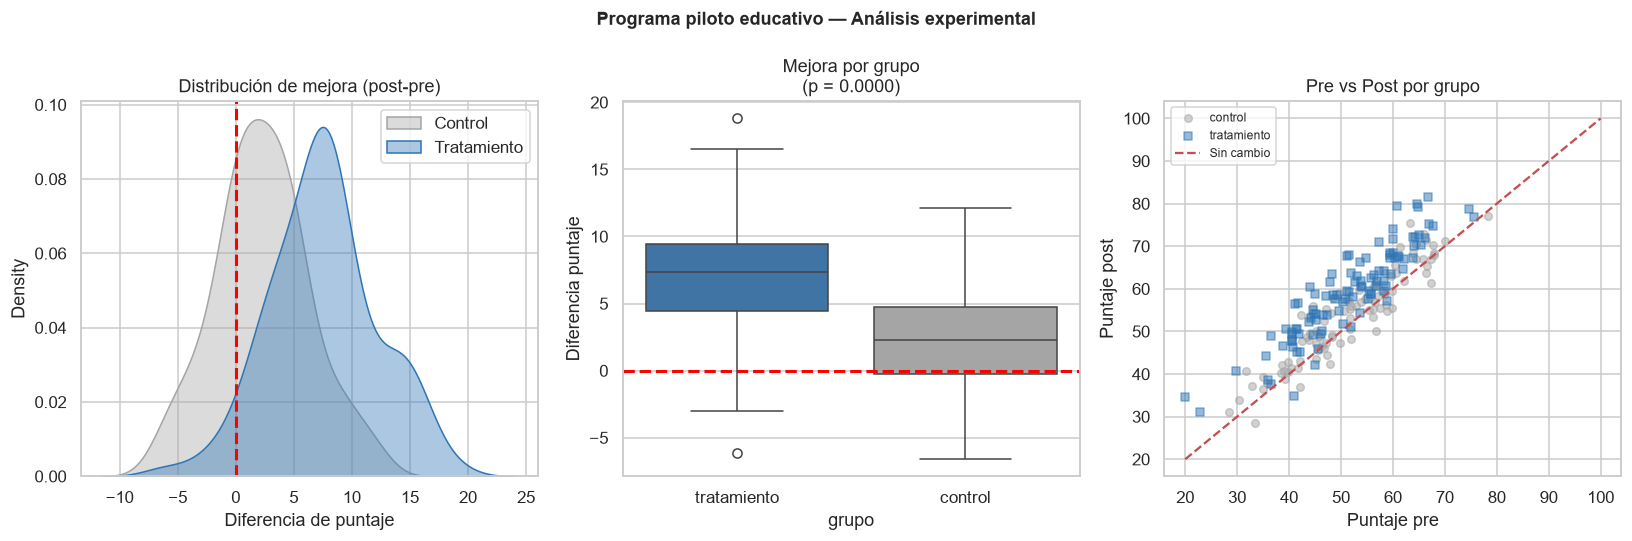

In [17]:
# Visualización del experimento
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Programa piloto educativo — Análisis experimental', fontweight='bold', fontsize=12)

# Distribución de diferencias por grupo
for grupo, color, label in [('control','#A5A5A5','Control'), ('tratamiento','#2E75B6','Tratamiento')]:
    sns.kdeplot(df[df['grupo']==grupo]['diferencia'],
                ax=axes[0], fill=True, alpha=0.4, color=color, label=label)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribución de mejora (post-pre)')
axes[0].set_xlabel('Diferencia de puntaje')
axes[0].legend()

# Boxplot comparativo
sns.boxplot(data=df, x='grupo', y='diferencia',
            palette={'control':'#A5A5A5','tratamiento':'#2E75B6'}, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'Mejora por grupo\n(p = {p_val:.4f})')
axes[1].set_ylabel('Diferencia puntaje')

# Puntaje pre vs post
for grupo, color, mk in [('control','#A5A5A5','o'), ('tratamiento','#2E75B6','s')]:
    sub = df[df['grupo']==grupo]
    axes[2].scatter(sub['puntaje_pre'], sub['puntaje_post'],
                    color=color, alpha=0.5, s=25, marker=mk, label=grupo)
lim = [20, 100]
axes[2].plot(lim, lim, 'r--', linewidth=1.5, label='Sin cambio')
axes[2].set_title('Pre vs Post por grupo')
axes[2].set_xlabel('Puntaje pre')
axes[2].set_ylabel('Puntaje post')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## PARTE 7 — Actividad guiada: ¿Es confiable este estudio? (slides 29-32)

### 7.1 Cargar datos de la ONG

In [18]:
df_ong = pd.read_csv('bienestar_ong.csv')
print(f'Registros: {len(df_ong)}')
print(df_ong.head(8))
print()
print('=== Grupos en el dataset ===')
print(df_ong['grupo'].value_counts())
print()
print('=== Mejora promedio ===')
print(f"Diferencia media: {df_ong['diferencia'].mean():.2f} puntos")

Registros: 60
  id_empleado   empresa         area  edad         grupo  puntaje_pre  \
0      EMP001  EmpresaA         RRHH    35  intervencion         66.0   
1      EMP002  EmpresaA  Operaciones    50  intervencion         25.8   
2      EMP003  EmpresaA         RRHH    34  intervencion         59.8   
3      EMP004  EmpresaA     Finanzas    51  intervencion         54.4   
4      EMP005  EmpresaA  Operaciones    54  intervencion         39.8   
5      EMP006  EmpresaA     Finanzas    29  intervencion         53.9   
6      EMP007  EmpresaA         RRHH    54  intervencion         71.5   
7      EMP008  EmpresaA  Operaciones    28  intervencion         49.1   

   puntaje_post  diferencia  
0          83.8        17.8  
1          38.0        12.2  
2          70.3        10.5  
3          61.6         7.2  
4          43.0         3.2  
5          62.8         8.9  
6          73.8         2.3  
7          56.2         7.1  

=== Grupos en el dataset ===
grupo
intervencion    60
Nam

In [19]:
# Análisis del estudio tal como está (con los problemas del diseño)
t_ong, p_ong = stats.ttest_1samp(df_ong['diferencia'], popmean=0)

print('=== Análisis pre-post SIN grupo control (diseño del estudio ONG) ===')
print(f'N:          {len(df_ong)}')
print(f'Media pre:  {df_ong["puntaje_pre"].mean():.2f}')
print(f'Media post: {df_ong["puntaje_post"].mean():.2f}')
print(f'Mejora:     {df_ong["diferencia"].mean():.2f} puntos')
print(f'Valor p:    {p_ong:.6f}')
print()
if p_ong < 0.05:
    print('✅ p < 0.05 → Diferencia estadísticamente significativa')
    print('Pero... ¿es realmente el programa la causa?')

=== Análisis pre-post SIN grupo control (diseño del estudio ONG) ===
N:          60
Media pre:  55.82
Media post: 64.43
Mejora:     8.61 puntos
Valor p:    0.000000

✅ p < 0.05 → Diferencia estadísticamente significativa
Pero... ¿es realmente el programa la causa?


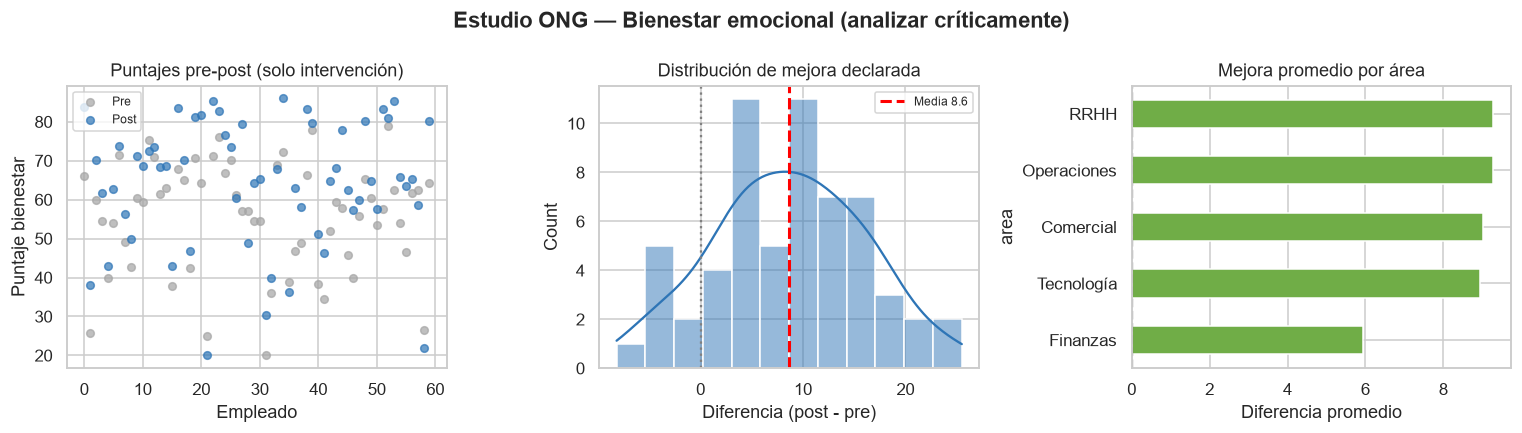

In [20]:
# Visualización del estudio de la ONG
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Estudio ONG — Bienestar emocional (analizar críticamente)',
             fontweight='bold')

# Pre vs post (sin grupo control)
axes[0].scatter(range(len(df_ong)), df_ong['puntaje_pre'],
                color='#A5A5A5', s=25, alpha=0.7, label='Pre')
axes[0].scatter(range(len(df_ong)), df_ong['puntaje_post'],
                color='#2E75B6', s=25, alpha=0.7, label='Post')
axes[0].set_title('Puntajes pre-post (solo intervención)')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Empleado')
axes[0].set_ylabel('Puntaje bienestar')

# Distribución de diferencias
sns.histplot(df_ong['diferencia'], bins=12, kde=True, ax=axes[1], color='#2E75B6')
axes[1].axvline(df_ong['diferencia'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Media {df_ong["diferencia"].mean():.1f}')
axes[1].axvline(0, color='gray', linestyle=':', linewidth=1.5)
axes[1].set_title('Distribución de mejora declarada')
axes[1].set_xlabel('Diferencia (post - pre)')
axes[1].legend(fontsize=8)

# Mejora por área
tasa_area = df_ong.groupby('area')['diferencia'].mean().sort_values()
tasa_area.plot(kind='barh', ax=axes[2], color='#70AD47', edgecolor='white')
axes[2].axvline(0, color='gray', linestyle='--')
axes[2].set_title('Mejora promedio por área')
axes[2].set_xlabel('Diferencia promedio')

plt.tight_layout()
plt.show()

### 7.2 Evaluar críticamente el diseño — instrucciones slides 31-32

In [21]:
# ✏️ Preguntas del slide 32 — evaluación crítica del estudio

# 1. ¿Qué elementos del diseño experimental están ausentes o mal implementados?
debilidades = [
    '',   # ✏️ Ejemplo: sin grupo control
    '',   # ✏️
    '',   # ✏️
]

# 2. ¿Qué tipo de inferencia se intenta hacer y qué tan válida es?
tipo_inferencia = ""
validez_inferencia = ""

# 3. ¿Se considera la significancia estadística del cambio observado?
sobre_significancia = ""

# 4. Propón 3 mejoras metodológicas (mínimo)
mejoras = [
    '',   # ✏️ Ejemplo: agregar grupo control en otra empresa
    '',   # ✏️
    '',   # ✏️
]

print('═'*65)
print('  EVALUACIÓN CRÍTICA DEL ESTUDIO ONG (slides 31-32)')
print('═'*65)
print()
print('1. Debilidades metodológicas:')
for d in debilidades:
    print(f'   • {d}')
print()
print('2. Tipo de inferencia y validez:')
print(f'   Tipo: {tipo_inferencia}')
print(f'   Validez: {validez_inferencia}')
print()
print('3. Sobre la significancia estadística:')
print(f'   {sobre_significancia}')
print()
print('4. Mejoras metodológicas propuestas:')
for m in mejoras:
    print(f'   ✅ {m}')
print('═'*65)

═════════════════════════════════════════════════════════════════
  EVALUACIÓN CRÍTICA DEL ESTUDIO ONG (slides 31-32)
═════════════════════════════════════════════════════════════════

1. Debilidades metodológicas:
   • 
   • 
   • 

2. Tipo de inferencia y validez:
   Tipo: 
   Validez: 

3. Sobre la significancia estadística:
   

4. Mejoras metodológicas propuestas:
   ✅ 
   ✅ 
   ✅ 
═════════════════════════════════════════════════════════════════


In [22]:
# Comparación: diseño actual (ONG) vs diseño mejorado (con grupo control)
tabla_comp_disenio = pd.DataFrame({
    'Elemento': [
        'Grupo control',
        'Asignación aleatoria',
        'Tamaño de muestra',
        'Representatividad',
        'Tipo de diseño',
        'Inferencia válida',
        'Generalizable'
    ],
    'Diseño actual ONG': [
        '❌ Ausente',
        '❌ Voluntarios (sesgo)',
        '⚠️ n=30 (pequeño)',
        '❌ 1 empresa sola',
        'Pre-experimental',
        '⚠️ Limitada',
        '❌ No'
    ],
    'Diseño mejorado': [
        '✅ Necesario',
        '✅ Aleatoria',
        '✅ n ≥ 100 por grupo',
        '✅ Múltiples empresas/sectores',
        'Experimental puro o cuasi-exp.',
        '✅ Alta',
        '✅ Sí'
    ]
})
print('=== Diagnóstico del diseño ===')
print(tabla_comp_disenio.to_string(index=False))

=== Diagnóstico del diseño ===
            Elemento     Diseño actual ONG                Diseño mejorado
       Grupo control             ❌ Ausente                    ✅ Necesario
Asignación aleatoria ❌ Voluntarios (sesgo)                    ✅ Aleatoria
   Tamaño de muestra     ⚠️ n=30 (pequeño)            ✅ n ≥ 100 por grupo
   Representatividad      ❌ 1 empresa sola  ✅ Múltiples empresas/sectores
      Tipo de diseño      Pre-experimental Experimental puro o cuasi-exp.
   Inferencia válida           ⚠️ Limitada                         ✅ Alta
       Generalizable                  ❌ No                           ✅ Sí


### ✏️ Preguntas de cierre — slide 35:

In [23]:
p1 = ""  # ¿Qué caracteriza al pensamiento estadístico?
p2 = ""  # ¿Cómo influye la estadística en el diseño y validez de una investigación?
p3 = ""  # ¿Qué es la inferencia estadística y en qué contextos se aplica?
p4 = ""  # ¿Qué significa que un resultado sea estadísticamente significativo?
p5 = ""  # ¿Cuáles son los elementos básicos de un diseño experimental riguroso?

preguntas = [
    '¿Qué caracteriza al pensamiento estadístico y por qué es esencial en ciencia?',
    '¿Cómo influye la estadística en el diseño y validez de una investigación?',
    '¿Qué es la inferencia estadística y en qué contextos se aplica?',
    '¿Qué significa que un resultado sea estadísticamente significativo?',
    '¿Cuáles son los elementos básicos de un diseño experimental riguroso?'
]

print('--- PREGUNTAS DE CIERRE (slide 35) ---')
for i, (preg, resp) in enumerate(zip(preguntas, [p1,p2,p3,p4,p5]), 1):
    print(f'\n{i}. {preg}')
    print(f'   R: {resp}')

--- PREGUNTAS DE CIERRE (slide 35) ---

1. ¿Qué caracteriza al pensamiento estadístico y por qué es esencial en ciencia?
   R: 

2. ¿Cómo influye la estadística en el diseño y validez de una investigación?
   R: 

3. ¿Qué es la inferencia estadística y en qué contextos se aplica?
   R: 

4. ¿Qué significa que un resultado sea estadísticamente significativo?
   R: 

5. ¿Cuáles son los elementos básicos de un diseño experimental riguroso?
   R: 


---
## 📋 Resumen

### Pensamiento estadístico

| Componente | ¿Qué implica en la práctica? |
|-----------|-----------------------------|
| Contextualización | Nunca analices datos sin entender su origen |
| Variabilidad | Cuantifícala siempre; la media sola es insuficiente |
| Modelos probabilísticos | Permite predecir con incertidumbre cuantificada |
| Decisión informada | Evidencia empírica > intuición |

### Inferencia y significancia

| Concepto | Código Python | Interpretación |
|---------|--------------|----------------|
| Prueba t | `stats.ttest_ind(g1, g2)` | ¿Difieren significativamente dos grupos? |
| Intervalo de confianza | `stats.t.interval(0.95, ...)` | Rango donde está el parámetro con 95% de certeza |
| Valor p | `p_valor` del test | Si p < α, rechazar H₀ |
| Error estándar | `stats.sem(datos)` | Incertidumbre de la media muestral |

### Diseño experimental

| Tipo | Validez | Cuándo usar |
|------|---------|-------------|
| Pre-experimental | Baja | Exploración inicial |
| Cuasi-experimental | Moderada | Sin posibilidad de aleatorizar |
| Experimental puro | Alta (estándar de oro) | Cuando se puede controlar todo |

> 💡 **Significancia ≠ Relevancia.** Un p < 0.05 con n=10.000 puede detectar diferencias de 0.1 puntos. Siempre pregunta: ¿es prácticamente importante esta diferencia?

> 💡 **Sin grupo control, no hay causalidad.** El estudio de la ONG detectó mejoras, pero sin grupo control no puede atribuirlas al programa. La mejora podría deberse al tiempo, efecto Hawthorne u otras causas.